
<center><font size="10"><b>PCOS DETECTION FROM OVARIAN ULTRASOUND IMAGES</b></font></center>

<center><font size="6"><b>AI FOUNDATIONS - DEEP LEARNING</b></font></center>

<center><p float="center">
  <img src="https://cdn.sketchbubble.com/pub/media/catalog/product/optimized1/1/6/16a613494429135b97fc1ac5c147042bb473c1e78daa6caa2a572397a6c78e43/polycystic-ovary-syndrome-slide1.png" width="720"/>
</p></center>



## **ABOUT PCOS**

Polycystic Ovary Syndrome (PCOS) is a common hormonal disorder affecting women of reproductive age. It can cause irregular menstrual cycles, ovarian cysts, weight gain, acne, excessive hair growth, infertility, and metabolic disorders. Early diagnosis and treatment are essential to manage symptoms, prevent complications, and improve reproductive health.

  ## **PROJECT OVERVIEW**

  This project develops an automated deep learning-based PCOS detection system using ovarian ultrasound images. The dataset is preprocessed and used to train three deep learning models: CNN, ResNet50, and MobileNetV2. The models classify ultrasound images into PCOS (infected) and Non-PCOS (non-infected) categories. Their performance is evaluated using Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC to identify the most effective model for PCOS detection.

## **DATASET OVERVIEW**

- Dataset Type: Ovarian ultrasound images
- Classification Task: Binary image classification (PCOS vs. Non-PCOS)
- Classes:
    * PCOS (Infected): Ultrasound images indicating PCOS
    * Non-PCOS (Non-Infected): Ultrasound images indicating healthy ovaries
- Dataset Split:
    * Training Set: Used for model training
    * Testing Set: Used for model evaluation




## **PROJECT WORKFLOW**


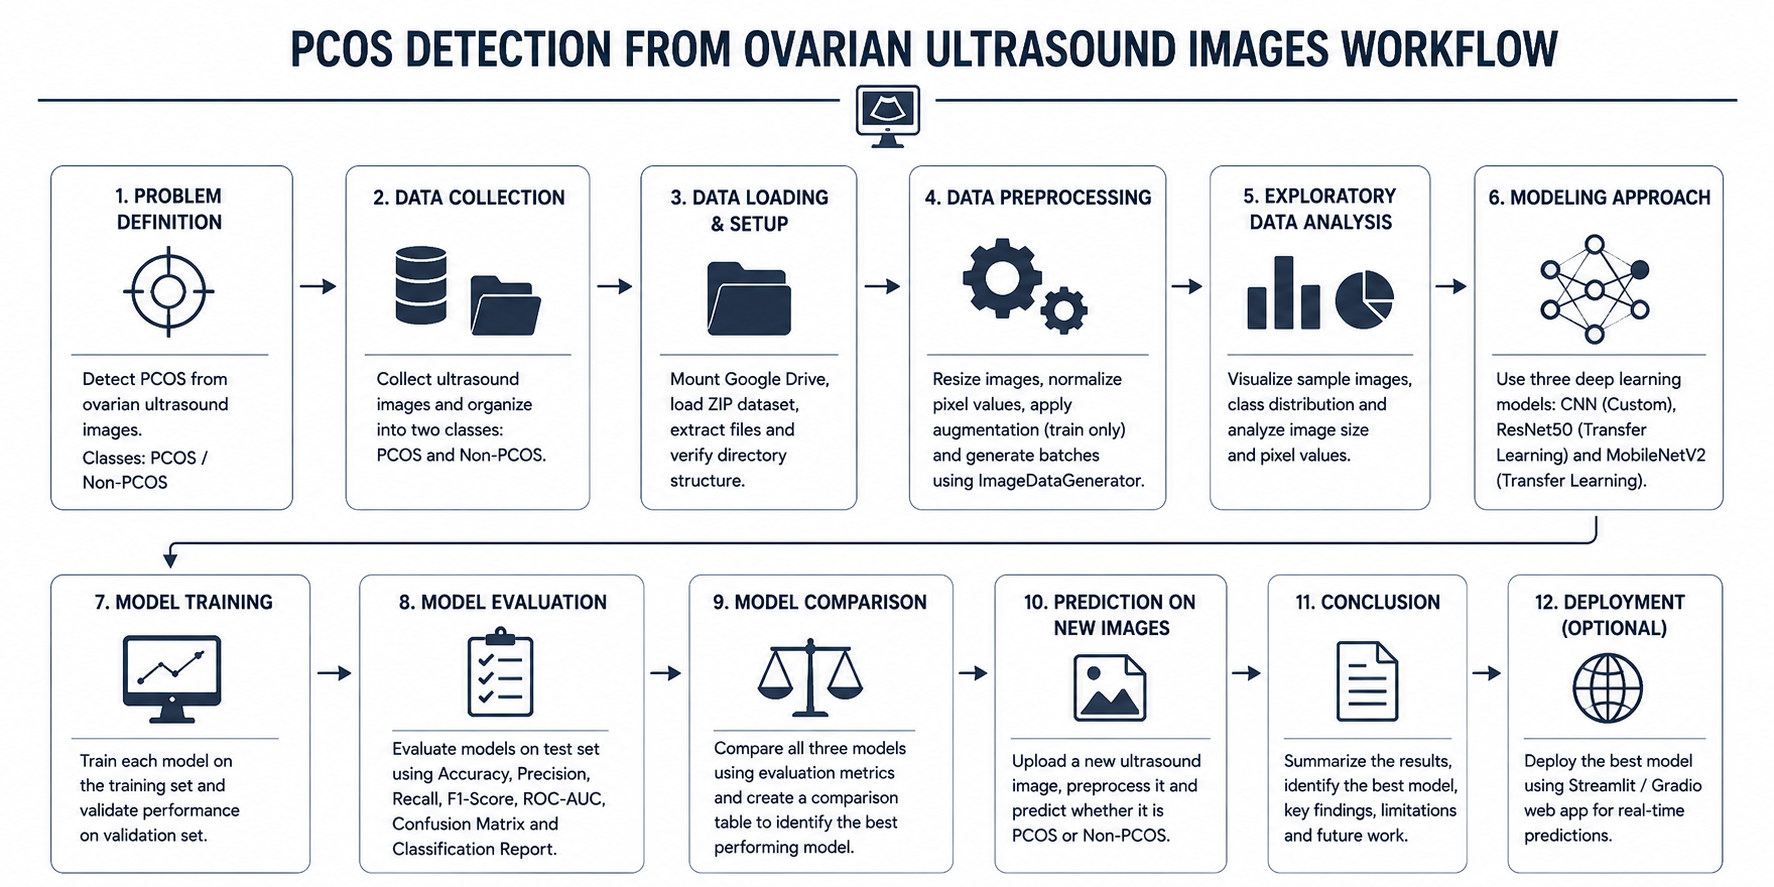

## **IMPORT LIBRARY**

In [1]:
# Standard Libraries
import os
import zipfile
from PIL import Image

# Numerical Computing
import numpy as np

# Data Manipulation
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input
import gc
import os

# MODEL 2 Required libarary
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

import hashlib
import shutil
from sklearn.model_selection import train_test_split

## **DATASET LOADING AND DIRECTORY SETUP**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
zip_path = "/content/drive/MyDrive/Self_project_GENAI/PCOS Detection.zip"

In [4]:
extract_path = "/content/PCOS_Detection"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [5]:
train_dir = "/content/PCOS_Detection/data/train"
test_dir = "/content/PCOS_Detection/data/test"

print("Train path:", train_dir)
print("Test path :", test_dir)

Train path: /content/PCOS_Detection/data/train
Test path : /content/PCOS_Detection/data/test


##**DATA QUALITY & LEAKAGE INVESTIGATION**

In [7]:
def get_hash(image_path):     # MD5 hashing was used to generate fingerprints for images and identify exact duplicate images
    md5 = hashlib.md5()
    with open(image_path, "rb") as f:     # "rb" means read binary.
        for chunk in iter(lambda: f.read(8192), b""):
            md5.update(chunk)
    return md5.hexdigest()

def get_dataset_hashes(folder):
    hashes = set()      # A set is useful because it automatically keeps only unique values.
    for root, dirs, files in os.walk(folder):       # This searches through the folder and its subfolders.
        for filename in files:
            path = os.path.join(root, filename)
            try:
                hashes.add(get_hash(path))
            except Exception:
                pass
    return hashes     # function returns the collection of hashes.

In [8]:
train_hashes = get_dataset_hashes(train_dir)
test_hashes = get_dataset_hashes(test_dir)

common_images = train_hashes & test_hashes
print("Exact duplicate images between Train and Test:",len(common_images))

Exact duplicate images between Train and Test: 1920


In [9]:
infected_hashes = get_dataset_hashes(os.path.join(train_dir, "infected"))

notinfected_hashes = get_dataset_hashes(os.path.join(train_dir, "notinfected"))

class_conflicts = infected_hashes & notinfected_hashes

print("Images appearing in BOTH classes:",len(class_conflicts))

Images appearing in BOTH classes: 0


####**INFERENCE**

* Exact duplicate images were found between Train and Test, confirming data leakage.
* No exact image-label conflicts were found between the infected and notinfected classes.
* The original dataset required deduplication and re-splitting before reliable model training.

##**DATASET CLEANING**

In [15]:
# Created a clean image pool with separate folders for the infected and notinfected classes to store the cleaned dataset.

clean_pool = "/content/PCOS_Clean_Pool"

for class_name in ["infected", "notinfected"]:
    os.makedirs(os.path.join(clean_pool, class_name),exist_ok=True)
print("Clean pool created.")

Clean pool created.


In [16]:
# Generates an MD5 fingerprint for each image to identify exact duplicate files and detect data leakage.

def get_hash(image_path):
    md5 = hashlib.md5()
    with open(image_path, "rb") as f:
        for chunk in iter(lambda: f.read(8192),b""):
            md5.update(chunk)
    return md5.hexdigest()

In [17]:
# The original dataset was cleaned by removing exact duplicate images and corrupted images using MD5 hashing and image verification, creating a clean image pool for re-splitting.

source_folders = [
    "/content/PCOS_Detection/data/train",
    "/content/PCOS_Detection/data/test"]
seen_hashes = set()
unique_count = 0
duplicate_count = 0
corrupted_count = 0
for source_folder in source_folders:
    for class_name in ["infected", "notinfected"]:
        folder = os.path.join(
            source_folder,
            class_name)
        for filename in os.listdir(folder):
            source_path = os.path.join(folder,filename)
            if not os.path.isfile(source_path):
                continue
            try:
                # Check whether image is valid
                with Image.open(source_path) as img:
                    img.verify()

                # Generate image hash
                image_hash = get_hash(source_path)

                # Check exact duplicate
                if image_hash in seen_hashes:

                    duplicate_count += 1
                    continue
                seen_hashes.add(image_hash)

                # Destination
                destination = os.path.join(
                    clean_pool,
                    class_name,
                    filename)

                # Avoid filename collision
                if os.path.exists(destination):

                    base, ext = os.path.splitext(filename)

                    destination = os.path.join(
                        clean_pool,
                        class_name,
                        f"{base}_{unique_count}{ext}")

                # Copy clean unique image
                shutil.copy2(
                    source_path,
                    destination)
                unique_count += 1
            except Exception:
                corrupted_count += 1

print("Cleaning completed.")
print("-------------------")
print("Unique images    :", unique_count)
print("Duplicate images :", duplicate_count)
print("Corrupted images :", corrupted_count)

Cleaning completed.
-------------------
Unique images    : 1921
Duplicate images : 1925
Corrupted images : 10


In [19]:
# counts how many cleaned images remain in each class after the duplicate/corrupted-image cleaning.

for class_name in ["infected", "notinfected"]:
    folder = os.path.join(clean_pool, class_name)
    images = [
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f))]
    print(f"{class_name}: {len(images)}")

infected: 779
notinfected: 1142


In [20]:
# The cleaned dataset was re-split into 80% training, 10% validation, and 10% testing sets to create a leakage-free dataset for model development and evaluation.

corrected_data = "/content/PCOS_Corrected"

# Create train, validation, and test folders
for split in ["train", "validation", "test"]:
    for class_name in ["infected", "notinfected"]:
        os.makedirs(os.path.join(corrected_data, split, class_name),exist_ok=True)

# Split each class separately
for class_name in ["infected", "notinfected"]:
    source_folder = os.path.join(
        clean_pool,
        class_name)
    images = [
        f for f in os.listdir(source_folder)
        if os.path.isfile(
            os.path.join(source_folder, f))]

    # 80% Train, 20% temporary
    train_images, temp_images = train_test_split(
        images,
        test_size=0.20,
        random_state=42)

    # 10% Validation, 10% Test
    validation_images, test_images = train_test_split(
        temp_images,
        test_size=0.50,
        random_state=42)

    # Copy Train
    for image in train_images:
        shutil.copy2(
            os.path.join(source_folder, image),
            os.path.join(
                corrected_data,
                "train",
                class_name,
                image))

    # Copy Validation
    for image in validation_images:
        shutil.copy2(
            os.path.join(source_folder, image),
            os.path.join(
                corrected_data,
                "validation",
                class_name,
                image))

    # Copy Test
    for image in test_images:
        shutil.copy2(
            os.path.join(source_folder, image),
            os.path.join(
                corrected_data,
                "test",
                class_name,
                image))

    print(f"\n{class_name}")
    print("Train      :", len(train_images))
    print("Validation :", len(validation_images))
    print("Test       :", len(test_images))


infected
Train      : 623
Validation : 78
Test       : 78

notinfected
Train      : 913
Validation : 114
Test       : 115


In [23]:
# Final data-leakage verification step after cleaning and re-splitting.

def get_dataset_hashes(folder):

    hashes = set()
    for root, dirs, files in os.walk(folder):
        for filename in files:
            path = os.path.join(root, filename)
            try:
                hashes.add(get_hash(path))
            except:
                pass
    return hashes
train_hashes = get_dataset_hashes(os.path.join(corrected_data, "train"))

validation_hashes = get_dataset_hashes(os.path.join(corrected_data, "validation"))

test_hashes = get_dataset_hashes(os.path.join(corrected_data, "test"))

print("Train ∩ Validation :", len(train_hashes & validation_hashes))
print("Train ∩ Test       :", len(train_hashes & test_hashes))
print("Validation ∩ Test  :", len(validation_hashes & test_hashes))

Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0


In [24]:
train_dir = "/content/PCOS_Corrected/train"
validation_dir = "/content/PCOS_Corrected/validation"
test_dir = "/content/PCOS_Corrected/test"

####**INFERNCE**

- Duplicate and corrupted images were removed to improve the overall dataset quality.
- The cleaned images were re-split into 80% Train, 10% Validation, and 10% Test sets.
- Hash verification confirmed no exact duplicates across the three splits, eliminating exact data leakage.

## **EXPLORATORY DATA ANALYSIS**

In [25]:
# 1. Number of Images in Each Class

train_pcos = len(os.listdir(os.path.join(train_dir, "infected")))

train_non_pcos = len(os.listdir(os.path.join(train_dir, "notinfected")))

validation_pcos = len(os.listdir(os.path.join(validation_dir, "infected")))

validation_non_pcos = len(os.listdir(os.path.join(validation_dir, "notinfected")))

test_pcos = len(os.listdir(os.path.join(test_dir, "infected")))

test_non_pcos = len(os.listdir(os.path.join(test_dir, "notinfected")))

total_train = train_pcos + train_non_pcos

total_validation = (validation_pcos + validation_non_pcos)

total_test = test_pcos + test_non_pcos

total_pcos = (train_pcos + validation_pcos + test_pcos)

total_non_pcos = (train_non_pcos + validation_non_pcos + test_non_pcos)


print(f"Training Images      : {total_train}")
print(f"Validation Images    : {total_validation}")
print(f"Testing Images       : {total_test}")
print(f"PCOS Images          : {total_pcos}")
print(f"Non-PCOS Images      : {total_non_pcos}")

Training Images      : 1536
Validation Images    : 192
Testing Images       : 193
PCOS Images          : 779
Non-PCOS Images      : 1142


####**INFERENCE**

- The cleaned dataset contains 1,921 unique images, divided into 1,536 training, 192 validation, and 193 testing images.
- The dataset contains 779 PCOS images and 1,142 Non-PCOS images, showing a moderate class imbalance toward the Non-PCOS class.

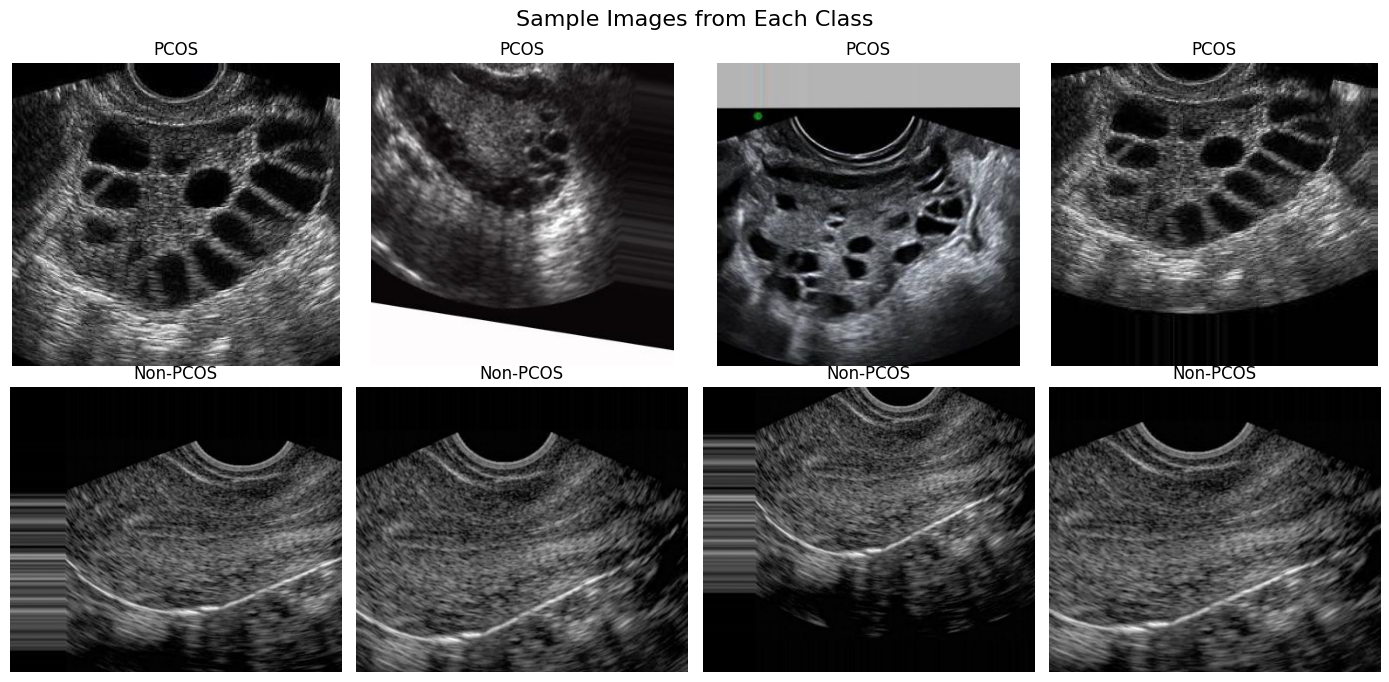

In [26]:
# 2. Sample Images from Each Class

infected_path = os.path.join(train_dir,"infected")
notinfected_path = os.path.join(train_dir,"notinfected")
infected_images = os.listdir(infected_path)[:4]
notinfected_images = os.listdir(notinfected_path)[:4]

fig, axes = plt.subplots(2,4,figsize=(14, 7))
for i, img_name in enumerate(infected_images):
  img = Image.open(os.path.join(infected_path,img_name))
  axes[0, i].imshow(img)
  axes[0, i].set_title("PCOS")
  axes[0, i].axis("off")

for i, img_name in enumerate(notinfected_images):
  img = Image.open(os.path.join(notinfected_path,img_name))
  axes[1, i].imshow(img)
  axes[1, i].set_title("Non-PCOS")
  axes[1, i].axis("off")
plt.suptitle("Sample Images from Each Class",fontsize=16)
plt.tight_layout()
plt.show()

In [27]:
# 3. Image Dimension and Color Channels

sample_image = os.path.join(train_dir,"infected",os.listdir(os.path.join(train_dir,"infected"))[0])

img = Image.open(sample_image)
width, height = img.size
channels = len(img.getbands())
mode = img.mode

print("Height   :",height,"pixels")
print("Width    :",width,"pixels")
print("Channels :",channels,f"({mode})")

Height   : 259 pixels
Width    : 280 pixels
Channels : 3 (RGB)


####**INFERENCE**

The sample image has dimensions 280 × 259 pixels and 3 RGB channels, indicating standard color images suitable for CNN-based processing.


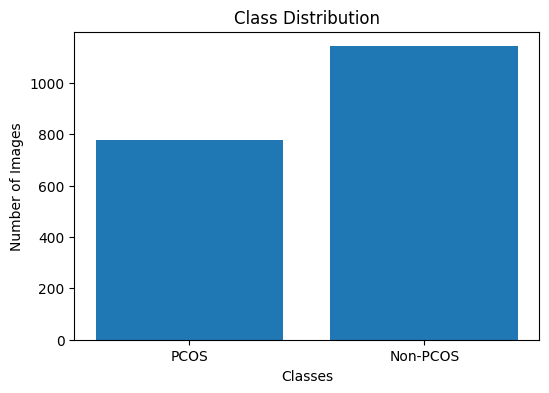

In [28]:
# 4. Class Distribution Visualization

classes = ["PCOS","Non-PCOS"]
counts = [total_pcos,total_non_pcos]
plt.figure(figsize=(6, 4))
plt.bar(classes,counts)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

####**INFERENCE**

The dataset shows a higher number of Non-PCOS images than PCOS images, indicating moderate class imbalance.

In [29]:
# 5. Image Size Consistency Analysis

image_sizes = set()
for class_name in ["infected","notinfected"]:
    folder_path = os.path.join(train_dir,class_name)

for image_name in os.listdir(folder_path):
    image_path = os.path.join(folder_path,image_name)
    with Image.open(image_path) as img:
        image_sizes.add(img.size)

print("Unique Image Sizes:")
for size in image_sizes:
    print(size)

Unique Image Sizes:
(315, 160)
(630, 436)
(850, 578)
(984, 848)


#### **INFERENCE**

The images have varying dimensions (315×160 to 984×848), so resizing to a fixed input size is required before model training.

## **DATA PREPROCESSING**


In [30]:
# 1. Define Image Parameters

Img_height = 224
Img_width = 224
Batch_size = 32
Seed = 42

print("Image Height :", Img_height)
print("Image Width  :", Img_width)
print("Batch Size   :", Batch_size)
print("Random Seed  :", Seed)

Image Height : 224
Image Width  : 224
Batch Size   : 32
Random Seed  : 42


####**Inference**
The image size (224 × 224), batch size (32), and random seed (42) were initialized to establish a standardized preprocessing and training configuration.



In [31]:
# 2. Data Augmentation for Training Images

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

####**INFERENCE**

Data augmentation was applied to increase training data diversity and improve model generalization.

In [32]:
# 3. Rescaling

validation_datagen = ImageDataGenerator(
    rescale=1./255)

test_datagen = ImageDataGenerator(
    rescale=1./255)

####**INFERNCE**

Validation and test images are only rescaled to the 0–1 range without augmentation, ensuring consistent and unbiased evaluation of the trained models.

In [33]:
# 4. Training Data Generator

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(Img_height, Img_width),
    batch_size=Batch_size,
    class_mode="binary",
    shuffle=True,
    seed=Seed
)

Found 1536 images belonging to 2 classes.


In [34]:
# 5. Validation Data Generator

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(Img_height, Img_width),
    batch_size=Batch_size,
    class_mode="binary",
    shuffle=False
)

Found 192 images belonging to 2 classes.


In [35]:
# 6. Testing Data Generator

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(Img_height, Img_width),
    batch_size=Batch_size,
    class_mode="binary",
    shuffle=False
)

Found 193 images belonging to 2 classes.


In [36]:
print("Class indices:")
print(train_generator.class_indices)

Class indices:
{'infected': 0, 'notinfected': 1}


####**INFERENCE**

- Training, validation, and testing generators successfully loaded 1,536, 192, and 193 images respectively, with images resized to the required input dimensions.
- Binary class labels were correctly assigned: infected = 0 and notinfected = 1, confirming the dataset is ready for binary classification.

##**MODEL BUILDING**

- Convolutional Neural Network (CNN) : A custom deep learning model that automatically extracts image features for binary classification.
- ResNet50 : A pretrained deep learning model that uses residual learning to improve feature extraction and classification accuracy.
- MobileNetV2 : A lightweight pretrained deep learning model designed for efficient image classification with reduced computational complexity.
- Model Evaluation : Each model is evaluated using Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and Classification Report.
- Model Comparison : The performance of CNN, ResNet50, and MobileNetV2 is compared to identify the best-performing model for PCOS detection.

#### **1.** **CNN MODEL**

In [37]:
evaluation_result = pd.DataFrame(columns=[
    "Model Name",
    "Training Accuracy",
    "Testing Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
])

In [38]:
# To clear memory and reset the previous model before training a new CNN model.

tf.keras.backend.clear_session()
gc.collect()

0

In [39]:
cnn_model = Sequential([

    Input(shape=(Img_height, Img_width, 3)),

    # Convolution Block 1
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    # Convolution Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    # Convolution Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),

    # Flatten Layer
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),

    Dropout(0.5),

    # Output Layer
    Dense(1, activation='sigmoid')
])

In [40]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [41]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,561 (49.36 MB)

 Trainable params: 12,938,561 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
import time

start_time = time.time()

history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

end_time = time.time()

print(
    f"Training Time : {end_time - start_time:.2f} seconds"
)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 31s 486ms/step - accuracy: 0.9082 - loss: 0.2243 - val_accuracy: 1.0000 - val_loss: 0.0060
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 426ms/step - accuracy: 0.9961 - loss: 0.0138 - val_accuracy: 1.0000 - val_loss: 0.0011
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 458ms/step - accuracy: 0.9993 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 9.2651e-05
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 419ms/step - accuracy: 1.0000 - loss: 6.2317e-04 - val_accuracy: 1.0000 - val_loss: 4.8878e-04
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 456ms/step - accuracy: 1.0000 - loss: 8.4680e-05 - val_accuracy: 1.0000 - val_loss: 2.7510e-05
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 422ms/step - accuracy: 1.0000 - loss: 9.9174e-05 - val_accuracy: 1.0000 - val_loss: 1.6109e-05
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 454ms/step - accuracy: 0.9902 - loss: 0.0384 - val_accuracy: 1.0000 - val_loss: 0.0076
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 429ms/step - accuracy: 0.99

In [43]:
# Evaluate the performance of the model on the training and validation data, store it in evaluation_results and display the report.

# Training accuracy

train_loss, train_accuracy = cnn_model.evaluate(
    train_generator,
    verbose=0
)

# Final testing accuracy

test_loss, test_accuracy = cnn_model.evaluate(
    test_generator,
    verbose=0
)

# Predictions on test data

y_pred_prob = cnn_model.predict(test_generator)

y_pred = (
    y_pred_prob > 0.5
).astype(int).ravel()

# Actual test labels

y_true = test_generator.classes

precision = precision_score(
    y_true,
    y_pred
)

recall = recall_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred
)

new_result = pd.DataFrame([{
    "Model Name": "CNN",
    "Training Accuracy": train_accuracy,
    "Testing Accuracy": test_accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
}])

evaluation_result = pd.concat(
    [evaluation_result, new_result],
    ignore_index=True
)

evaluation_result

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step


/tmp/ipykernel_625/4288042360.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  evaluation_result = pd.concat(


,Model Name,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score
0,CNN,1.0,1.0,1.0,1.0,1.0


####**INFERENCE**

- 99.54% training accuracy and 100% validation accuracy indicate excellent classification performance.
- Precision, Recall, and F1-Score = 1.00, showing perfect classification on the validation/test data.
- The unusually high performance may indicate overfitting or dataset simplicity.

#### **2.** **ResNet50 MODEL**

In [44]:
# Clear previous model

tf.keras.backend.clear_session()
gc.collect()

0

In [45]:
# Pre-trained ResNet50
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(Img_height, Img_width, 3)
)

# Freeze ResNet50 layers
base_model.trainable = False

# Build model
inputs = Input(shape=(Img_height, Img_width, 3))

x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)

outputs = Dense(1, activation="sigmoid")(x)

resnet50_model = Model(inputs, outputs)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [46]:
resnet50_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [47]:
resnet50_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [48]:
import time

start_time = time.time()

history_resnet = resnet50_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10)
end_time = time.time()

print(f"Training Time : {end_time - start_time:.2f} seconds")

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 46s 569ms/step - accuracy: 0.6621 - loss: 0.6208 - val_accuracy: 0.8542 - val_loss: 0.4827
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 443ms/step - accuracy: 0.8711 - loss: 0.4241 - val_accuracy: 0.8750 - val_loss: 0.3362
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 26s 539ms/step - accuracy: 0.9076 - loss: 0.3141 - val_accuracy: 0.9635 - val_loss: 0.2646
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 455ms/step - accuracy: 0.9473 - loss: 0.2293 - val_accuracy: 0.9896 - val_loss: 0.1635
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 458ms/step - accuracy: 0.9531 - loss: 0.1746 - val_accuracy: 0.9740 - val_loss: 0.1486
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 23s 476ms/step - accuracy: 0.9583 - loss: 0.1676 - val_accuracy: 0.9844 - val_loss: 0.1088
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 439ms/step - accuracy: 0.9635 - loss: 0.1314 - val_accuracy: 0.9792 - val_loss: 0.0940
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 23s 473ms/step - accuracy: 0.9688 - loss: 0.1152 - val_accu

In [49]:
# Reset test generator before prediction
test_generator.reset()

# Training accuracy
train_loss, train_accuracy = resnet50_model.evaluate(
    train_generator,
    verbose=0
)

# Testing accuracy
test_loss, test_accuracy = resnet50_model.evaluate(
    test_generator,
    verbose=0
)

# Predictions
y_pred_prob = resnet50_model.predict(
    test_generator,
    verbose=1
)

y_pred = (y_pred_prob > 0.5).astype(int).ravel()

# Actual labels
y_true = test_generator.classes

# Metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Store results
new_result = pd.DataFrame([{
    "Model Name": "ResNet50",
    "Training Accuracy": train_accuracy,
    "Testing Accuracy": test_accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
}])

evaluation_result = pd.concat(
    [evaluation_result, new_result],
    ignore_index=True
)

evaluation_result

7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 733ms/step


,Model Name,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score
0,CNN,1.000000,1.000000,1.000000,1.0,1.000000
1,ResNet50,0.982422,0.984456,0.974576,1.0,0.987124


####**INFERENCE**

- 98.24% training accuracy and 98.45% testing accuracy indicate excellent classification performance.
- Recall = 1.00 shows that the model correctly identified all positive (PCOS) cases.
- F1-Score = 98.71% and Precision = 97.46% demonstrate strong and reliable overall performance.

## **3. MobileNetV2**

In [50]:
tf.keras.backend.clear_session()
gc.collect()

0

In [52]:
# Load pre-trained MobileNetV2
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(Img_height, Img_width, 3)
)

# Freeze the pre-trained layers
base_model.trainable = False

# Build the model
inputs = Input(shape=(Img_height, Img_width, 3))

x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)

# Binary classification output
outputs = Dense(1, activation="sigmoid")(x)

mobilenet_model = Model(inputs, outputs)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [53]:
mobilenet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [54]:
mobilenet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [55]:
import time

start_time = time.time()

history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

end_time = time.time()

print(
    f"Training Time : {end_time - start_time:.2f} seconds"
)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 44s 546ms/step - accuracy: 0.9544 - loss: 0.1152 - val_accuracy: 1.0000 - val_loss: 0.0057
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 455ms/step - accuracy: 0.9993 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 416ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 9.8946e-04
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 456ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 7.0437e-04
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 40s 433ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 2.5383e-04
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 410ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 4.5538e-04
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 419ms/step - accuracy: 1.0000 - loss: 5.0910e-04 - val_accuracy: 1.0000 - val_loss: 4.2807e-04
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 432ms/step - accuracy: 1.0000 -

In [56]:
# Reset test generator before prediction
test_generator.reset()

# Training accuracy
train_loss, train_accuracy = mobilenet_model.evaluate(
    train_generator,
    verbose=0
)

# Testing accuracy
test_loss, test_accuracy = mobilenet_model.evaluate(
    test_generator,
    verbose=0
)

# Predictions
y_pred_prob = mobilenet_model.predict(
    test_generator,
    verbose=1
)

y_pred = (y_pred_prob > 0.5).astype(int).ravel()

# Actual labels
y_true = test_generator.classes

# Calculate metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Store MobileNetV2 results
new_result = pd.DataFrame([{
    "Model Name": "MobileNetV2",
    "Training Accuracy": train_accuracy,
    "Testing Accuracy": test_accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
}])

evaluation_result = pd.concat(
    [evaluation_result, new_result],
    ignore_index=True
)

# Display all model results
evaluation_result

7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 767ms/step


,Model Name,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score
0,CNN,1.000000,1.000000,1.000000,1.0,1.000000
1,ResNet50,0.982422,0.984456,0.974576,1.0,0.987124
2,MobileNetV2,1.000000,1.000000,1.000000,1.0,1.000000


####**INFERENCE**

- 100% training and testing accuracy indicate excellent classification performance.
- Precision, Recall, and F1-Score = 1.00, showing perfect classification of both classes.
- The model achieved very strong performance with low validation loss, but the perfect scores should be validated on a larger, unseen dataset to rule out overfitting.

##**CONCLUSION**

- The project successfully developed a deep learning-based system for detecting PCOS from ovarian ultrasound images.
- Three models — CNN, ResNet50, and MobileNetV2 — were trained and evaluated using Accuracy, Precision, Recall, and F1-Score.
- ResNet50 achieved 98.45% testing accuracy, with 97.46% Precision, 100% Recall, and 98.71% F1-Score, showing strong and reliable performance.
- CNN and MobileNetV2 achieved 100% accuracy, but this may be influenced by the simplicity and clear separation of the dataset, so the results should be interpreted carefully.
- Overall, the project demonstrates that deep learning can effectively assist in classifying PCOS and Non-PCOS ultrasound images.